# Q2Q 4-Dataset Clustering: Candidate Pair Generation

This notebook generates candidate question pairs for human expert review using embedding-based
clustering across **4 datasets**: Arivale, Israeli10K, UKBB, and TwinsUK.

## Key Differences from 3-Dataset Version

1. **Threshold-first approach**: Cosine similarity threshold (0.5) applied BEFORE clustering
2. **TwinsUK integration**: ~7,908 additional questions from TwinsUK study
3. **Embedding caching**: Per-source `.npy` files for faster re-runs
4. **Direct vs transitive edges**: Labels distinguish best-match edges from cluster membership

## Scope

**This notebook**: Pair generation only  
**Separate notebook**: Human review analysis (after votes are collected)

## Data Flow

```
~9,482 questions (4 sources)
    ↓
Generate/load embeddings (cached per source)
    ↓
Find best cross-source match for each question
    ↓
Filter edges by threshold (≥0.5)
    ↓
Union-Find clustering on filtered edges
    ↓
Generate all cross-source pairs within clusters
    ↓
Export TSV for EITL upload
```

## Cell 1: Configuration & Imports

In [2]:
from __future__ import annotations

import hashlib
import json
from collections import defaultdict
from dataclasses import dataclass, field
from datetime import datetime, UTC
from itertools import combinations
from pathlib import Path
from typing import Any

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sentence_transformers import SentenceTransformer

# =============================================================================
# CONFIGURATION
# =============================================================================

# Clustering parameters
THRESHOLD = 0.5  # Cosine similarity threshold for edge creation
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

# All datasets to include
ALL_SOURCES = ["Arivale", "Israeli10K", "UKBB", "TwinsUK"]

# Paths
DATA_DIR = Path("../../data")
QUESTIONS_PATH = DATA_DIR / "questionnaires/processed/questions.json"
TWINSUK_PATH = DATA_DIR / "raw/TwinsUK_questionnaires.csv"
EMBEDDING_CACHE_DIR = DATA_DIR / "questionnaires/embeddings/questions"
OUTPUT_DIR = DATA_DIR / "review/q2q_4dataset"

# Existing pairs for vote migration
EXISTING_PAIRS_PATH = DATA_DIR / "review/q2q_expertintheloop.tsv"

# Create output directories
EMBEDDING_CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration:")
print(f"  Threshold: {THRESHOLD}")
print(f"  Embedding model: {EMBEDDING_MODEL}")
print(f"  Sources: {ALL_SOURCES}")
print(f"  Output directory: {OUTPUT_DIR}")

Configuration:
  Threshold: 0.5
  Embedding model: sentence-transformers/all-MiniLM-L6-v2
  Sources: ['Arivale', 'Israeli10K', 'UKBB', 'TwinsUK']
  Output directory: ../../data/review/q2q_4dataset


## Cell 2: Load & Prepare Data (Including TwinsUK)

In [3]:
# Load existing questions.json (3 datasets: Arivale, Israeli10K, UKBB)
print("Loading existing questions.json...")
with open(QUESTIONS_PATH) as f:
    questions = json.load(f)

print(f"Loaded {len(questions)} questions from questions.json")

# Load and parse TwinsUK CSV
print(f"\nLoading TwinsUK from {TWINSUK_PATH}...")
twinsuk_df = pd.read_csv(TWINSUK_PATH)
print(f"TwinsUK CSV rows: {len(twinsuk_df)}")

# Convert TwinsUK to same format as other questions
twinsuk_added = 0
twinsuk_skipped = 0
seen_texts = set()  # Track duplicates within TwinsUK

for idx, row in twinsuk_df.iterrows():
    text = str(row["Phenotype_Description"]).strip()
    
    # Skip empty or nan values
    if not text or text == "nan" or text.lower() == "nan":
        twinsuk_skipped += 1
        continue
    
    # Skip duplicates within TwinsUK
    if text in seen_texts:
        twinsuk_skipped += 1
        continue
    seen_texts.add(text)
    
    # Generate deterministic ID from text hash
    hash_val = hashlib.sha256(text.encode()).hexdigest()[:12]
    question_id = f"twinsuk_{hash_val}"
    
    # Build metadata with SNOMED terms if available
    metadata = {
        "source_questionnaire": "TwinsUK",
        "data_type": str(row.get("Data_Type", "")).strip() if pd.notna(row.get("Data_Type")) else "",
    }
    
    # Add SNOMED terms if present
    for i in range(1, 5):
        snomed_col = f"snomed_term_{i}"
        if snomed_col in row and pd.notna(row[snomed_col]):
            snomed_val = str(row[snomed_col]).strip()
            if snomed_val and snomed_val != "nan":
                metadata[snomed_col] = snomed_val
    
    questions.append({
        "id": question_id,
        "name": text,
        "synonyms": [],
        "metadata": metadata
    })
    twinsuk_added += 1

print(f"TwinsUK questions added: {twinsuk_added}")
print(f"TwinsUK questions skipped (empty/duplicate): {twinsuk_skipped}")
print(f"\nTotal questions: {len(questions)}")

Loading existing questions.json...
Loaded 1574 questions from questions.json

Loading TwinsUK from ../../data/raw/TwinsUK_questionnaires.csv...
TwinsUK CSV rows: 7872
TwinsUK questions added: 7801
TwinsUK questions skipped (empty/duplicate): 71

Total questions: 9375


In [4]:
# Group questions by source
questions_by_source: dict[str, list[dict]] = defaultdict(list)
question_lookup: dict[str, dict] = {}  # id -> question

for q in questions:
    source = q.get("metadata", {}).get("source_questionnaire", "Unknown")
    questions_by_source[source].append(q)
    question_lookup[q["id"]] = q

print("Questions by source:")
for source in ALL_SOURCES:
    count = len(questions_by_source.get(source, []))
    print(f"  {source}: {count}")

total = sum(len(questions_by_source.get(s, [])) for s in ALL_SOURCES)
print(f"\nTotal (4 sources): {total}")

# Validate all sources have data
for source in ALL_SOURCES:
    if source not in questions_by_source or len(questions_by_source[source]) == 0:
        raise ValueError(f"Missing data for source: {source}")

Questions by source:
  Arivale: 561
  Israeli10K: 514
  UKBB: 499
  TwinsUK: 7801

Total (4 sources): 9375


## Cell 3: Generate & Cache Embeddings

In [5]:
def load_or_compute_embeddings(
    questions_list: list[dict],
    model: SentenceTransformer,
    cache_path: Path
) -> np.ndarray:
    """Load cached embeddings or compute and cache them.
    
    Args:
        questions_list: List of question dictionaries with 'name' field
        model: SentenceTransformer model for encoding
        cache_path: Path to .npy cache file
    
    Returns:
        L2-normalized embeddings array of shape (n_questions, embedding_dim)
    """
    if cache_path.exists():
        print(f"  Loading cached embeddings from {cache_path.name}")
        embeddings = np.load(cache_path)
        
        # Validate cache matches current data
        if embeddings.shape[0] != len(questions_list):
            print(f"  ⚠️ Cache mismatch: {embeddings.shape[0]} cached vs {len(questions_list)} questions")
            print(f"  Recomputing embeddings...")
        else:
            return embeddings
    
    print(f"  Computing embeddings for {len(questions_list)} questions...")
    texts = [q["name"] for q in questions_list]
    
    embeddings = model.encode(
        texts,
        normalize_embeddings=True,  # L2 normalize for cosine similarity
        convert_to_numpy=True,
        show_progress_bar=True,
    )
    
    # Save to cache
    np.save(cache_path, embeddings)
    print(f"  Cached to {cache_path.name}")
    
    return embeddings


# Load embedding model
print(f"Loading embedding model: {EMBEDDING_MODEL}")
model = SentenceTransformer(EMBEDDING_MODEL)
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")

Loading embedding model: sentence-transformers/all-MiniLM-L6-v2
Embedding dimension: 384


In [6]:
# Generate/load embeddings for each source
@dataclass
class SourceIndex:
    """FAISS index and metadata for a single source."""
    source: str
    index: faiss.IndexFlatIP
    questions: list[dict[str, Any]]
    id_list: list[str]
    embeddings: np.ndarray


source_indices: dict[str, SourceIndex] = {}

print("\nBuilding source indices with cached embeddings...")
for source in ALL_SOURCES:
    qs = questions_by_source[source]
    print(f"\n{source} ({len(qs)} questions):")
    
    # Determine cache path
    cache_path = EMBEDDING_CACHE_DIR / f"{source.lower()}_embeddings.npy"
    
    # Load or compute embeddings
    embeddings = load_or_compute_embeddings(qs, model, cache_path)
    
    # Build FAISS index for efficient similarity search
    d = embeddings.shape[1]
    index = faiss.IndexFlatIP(d)  # Inner product = cosine sim for normalized vectors
    index.add(embeddings.astype(np.float32))
    
    # Store
    ids = [q["id"] for q in qs]
    source_indices[source] = SourceIndex(
        source=source,
        index=index,
        questions=qs,
        id_list=ids,
        embeddings=embeddings,
    )
    print(f"  Index built: {index.ntotal} vectors")

print("\n✓ All source indices built successfully!")


Building source indices with cached embeddings...

Arivale (561 questions):
  Computing embeddings for 561 questions...


Batches:   0%|          | 0/18 [00:00<?, ?it/s]

  Cached to arivale_embeddings.npy
  Index built: 561 vectors

Israeli10K (514 questions):
  Computing embeddings for 514 questions...


Batches:   0%|          | 0/17 [00:00<?, ?it/s]

  Cached to israeli10k_embeddings.npy
  Index built: 514 vectors

UKBB (499 questions):
  Computing embeddings for 499 questions...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

  Cached to ukbb_embeddings.npy
  Index built: 499 vectors

TwinsUK (7801 questions):
  Computing embeddings for 7801 questions...


Batches:   0%|          | 0/244 [00:00<?, ?it/s]

  Cached to twinsuk_embeddings.npy
  Index built: 7801 vectors

✓ All source indices built successfully!


## Cell 4: Best-Match-Per-Dataset Edge Generation

In [7]:
@dataclass
class BestMatchEdge:
    """An edge from a question to its best cross-source match."""
    source_id: str
    source_text: str
    source_survey: str
    target_id: str
    target_text: str
    target_survey: str
    similarity: float


# Define match targets: each source matches against all OTHER sources
def get_match_targets(source: str) -> list[str]:
    """Get list of other sources to match against."""
    return [s for s in ALL_SOURCES if s != source]


# Generate ALL best cross-source matches
all_edges: list[BestMatchEdge] = []

for source_name in ALL_SOURCES:
    source_idx = source_indices[source_name]
    target_sources = get_match_targets(source_name)
    
    print(f"\nMatching {source_name} against {target_sources}...")
    
    # Build combined index of all target sources
    target_questions: list[dict[str, Any]] = []
    target_embeddings_list: list[np.ndarray] = []
    target_source_labels: list[str] = []
    
    for target_name in target_sources:
        target_idx = source_indices[target_name]
        target_questions.extend(target_idx.questions)
        target_embeddings_list.append(target_idx.embeddings)
        target_source_labels.extend([target_name] * len(target_idx.questions))
    
    # Combine embeddings
    target_embeddings = np.vstack(target_embeddings_list)
    
    # Build combined FAISS index
    d = target_embeddings.shape[1]
    combined_index = faiss.IndexFlatIP(d)
    combined_index.add(target_embeddings.astype(np.float32))
    
    # Search for best match for each source question
    scores, indices = combined_index.search(source_idx.embeddings.astype(np.float32), 1)
    
    # Build edges
    edges_from_source = 0
    for i, source_q in enumerate(source_idx.questions):
        idx = indices[i, 0]
        if idx < 0:
            continue
        
        target_q = target_questions[idx]
        target_source = target_source_labels[idx]
        sim = float(scores[i, 0])
        
        all_edges.append(BestMatchEdge(
            source_id=source_q["id"],
            source_text=source_q["name"],
            source_survey=source_name,
            target_id=target_q["id"],
            target_text=target_q["name"],
            target_survey=target_source,
            similarity=sim,
        ))
        edges_from_source += 1
    
    print(f"  Generated {edges_from_source} edges")

print(f"\n=== Total edges: {len(all_edges)} ===")
print(f"(Expected: {len(questions)} - one edge per question)")


Matching Arivale against ['Israeli10K', 'UKBB', 'TwinsUK']...
  Generated 561 edges

Matching Israeli10K against ['Arivale', 'UKBB', 'TwinsUK']...
  Generated 514 edges

Matching UKBB against ['Arivale', 'Israeli10K', 'TwinsUK']...
  Generated 499 edges

Matching TwinsUK against ['Arivale', 'Israeli10K', 'UKBB']...
  Generated 7801 edges

=== Total edges: 9375 ===
(Expected: 9375 - one edge per question)


In [8]:
# Analyze edge similarity distribution
similarities = np.array([e.similarity for e in all_edges])

print("Edge Similarity Statistics")
print("=" * 40)
print(f"  Count:  {len(similarities)}")
print(f"  Min:    {similarities.min():.4f}")
print(f"  Max:    {similarities.max():.4f}")
print(f"  Mean:   {similarities.mean():.4f}")
print(f"  Median: {np.median(similarities):.4f}")
print(f"  Std:    {similarities.std():.4f}")

# Threshold analysis
print(f"\nEdges at various thresholds:")
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    count = (similarities >= thresh).sum()
    pct = count / len(similarities) * 100
    marker = " ← SELECTED" if thresh == THRESHOLD else ""
    print(f"  ≥ {thresh}: {count:5d} ({pct:5.1f}%){marker}")

Edge Similarity Statistics
  Count:  9375
  Min:    0.2232
  Max:    1.0000
  Mean:   0.5695
  Median: 0.5692
  Std:    0.1199

Edges at various thresholds:
  ≥ 0.3:  9296 ( 99.2%)
  ≥ 0.4:  8584 ( 91.6%)
  ≥ 0.5:  6662 ( 71.1%) ← SELECTED
  ≥ 0.6:  3757 ( 40.1%)
  ≥ 0.7:  1335 ( 14.2%)
  ≥ 0.8:   248 (  2.6%)


/tmp/ipykernel_3381563/2095429306.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_for_box, labels=ALL_SOURCES, patch_artist=True)


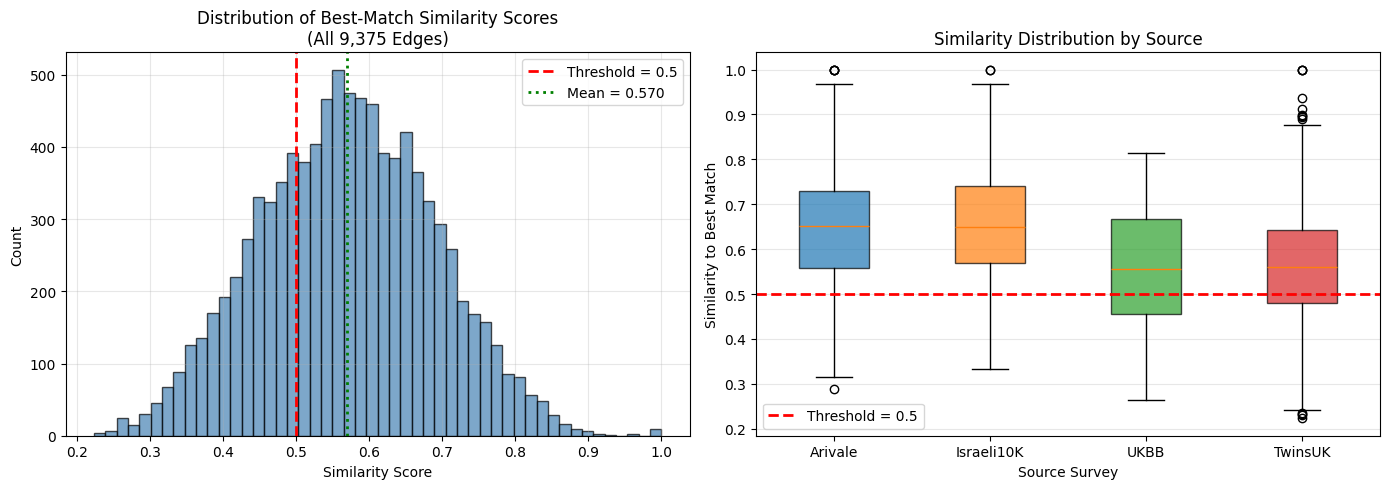


Saved: ../../data/review/q2q_4dataset/edge_similarity_distribution.png


In [9]:
# Visualize similarity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1 = axes[0]
ax1.hist(similarities, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(x=THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold = {THRESHOLD}')
ax1.axvline(x=similarities.mean(), color='green', linestyle=':', linewidth=2, label=f'Mean = {similarities.mean():.3f}')
ax1.set_xlabel('Similarity Score')
ax1.set_ylabel('Count')
ax1.set_title(f'Distribution of Best-Match Similarity Scores\n(All {len(similarities):,} Edges)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# By source direction
ax2 = axes[1]
direction_sims = defaultdict(list)
for e in all_edges:
    direction_sims[e.source_survey].append(e.similarity)

data_for_box = [direction_sims[s] for s in ALL_SOURCES]
bp = ax2.boxplot(data_for_box, labels=ALL_SOURCES, patch_artist=True)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.axhline(y=THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold = {THRESHOLD}')
ax2.set_xlabel('Source Survey')
ax2.set_ylabel('Similarity to Best Match')
ax2.set_title('Similarity Distribution by Source')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'edge_similarity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved: {OUTPUT_DIR / 'edge_similarity_distribution.png'}")

## Cell 5: Union-Find Clustering with Threshold

In [10]:
class UnionFind:
    """Disjoint set data structure for efficient clustering.
    
    Uses path compression and union by rank for O(α(n)) amortized operations,
    where α is the inverse Ackermann function (effectively constant).
    """
    
    def __init__(self):
        self.parent: dict[str, str] = {}
        self.rank: dict[str, int] = {}
    
    def find(self, x: str) -> str:
        """Find root of set containing x with path compression."""
        if x not in self.parent:
            self.parent[x] = x
            self.rank[x] = 0
            return x
        
        # Path compression: make all nodes point directly to root
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]
    
    def union(self, x: str, y: str) -> None:
        """Merge sets containing x and y using union by rank."""
        root_x = self.find(x)
        root_y = self.find(y)
        
        if root_x == root_y:
            return
        
        # Union by rank: attach smaller tree under larger
        if self.rank[root_x] < self.rank[root_y]:
            self.parent[root_x] = root_y
        elif self.rank[root_x] > self.rank[root_y]:
            self.parent[root_y] = root_x
        else:
            self.parent[root_y] = root_x
            self.rank[root_x] += 1
    
    def get_clusters(self) -> dict[str, list[str]]:
        """Return all clusters as {root_id: [member_ids]}."""
        clusters: dict[str, list[str]] = defaultdict(list)
        for x in self.parent:
            root = self.find(x)
            clusters[root].append(x)
        return dict(clusters)

In [11]:
# Build clusters using ONLY edges above threshold
# This is the key difference: threshold BEFORE clustering, not after

uf = UnionFind()

# First, add all questions as singleton nodes
for q in questions:
    uf.find(q["id"])

# Track which edges are used (direct edges)
direct_edges: set[tuple[str, str]] = set()
edges_used = 0
edges_filtered = 0

for edge in all_edges:
    if edge.similarity >= THRESHOLD:
        uf.union(edge.source_id, edge.target_id)
        # Store as sorted tuple for consistent lookup
        edge_key = tuple(sorted([edge.source_id, edge.target_id]))
        direct_edges.add(edge_key)
        edges_used += 1
    else:
        edges_filtered += 1

clusters = uf.get_clusters()

print(f"Clustering with threshold ≥ {THRESHOLD}")
print(f"  Edges used: {edges_used}")
print(f"  Edges filtered out: {edges_filtered}")
print(f"  Total clusters: {len(clusters)}")

Clustering with threshold ≥ 0.5
  Edges used: 6662
  Edges filtered out: 2713
  Total clusters: 3208


## Cell 6: Cluster Statistics

In [12]:
def analyze_clusters(clusters: dict[str, list[str]], label: str) -> dict:
    """Analyze clustering results."""
    print(f"\n{'=' * 60}")
    print(f"Cluster Analysis: {label}")
    print(f"{'=' * 60}")
    
    # Basic stats
    sizes = [len(members) for members in clusters.values()]
    total_questions = sum(sizes)
    
    print(f"\nTotal clusters: {len(clusters)}")
    print(f"Total questions: {total_questions}")
    print(f"\nCluster size statistics:")
    print(f"  Min size:    {min(sizes)}")
    print(f"  Max size:    {max(sizes)}")
    print(f"  Mean size:   {np.mean(sizes):.2f}")
    print(f"  Median size: {np.median(sizes):.1f}")
    
    # Size distribution
    size_counts = defaultdict(int)
    for size in sizes:
        if size == 1:
            size_counts["1 (singleton)"] += 1
        elif size <= 4:
            size_counts[str(size)] += 1
        elif size <= 10:
            size_counts["5-10"] += 1
        else:
            size_counts[">10 (suspicious)"] += 1
    
    print(f"\nSize distribution:")
    for key in ["1 (singleton)", "2", "3", "4", "5-10", ">10 (suspicious)"]:
        count = size_counts.get(key, 0)
        if count > 0:
            print(f"  Size {key}: {count} clusters")
    
    # Source coverage analysis
    source_coverage = defaultdict(int)
    coverage_by_n = {1: 0, 2: 0, 3: 0, 4: 0}
    
    for members in clusters.values():
        sources = set()
        for qid in members:
            if qid in question_lookup:
                src = question_lookup[qid].get("metadata", {}).get("source_questionnaire", "Unknown")
                sources.add(src)
        
        # Use abbreviations for readability
        abbrev = {
            "Arivale": "A",
            "Israeli10K": "I",
            "UKBB": "U",
            "TwinsUK": "T"
        }
        sources_key = "+".join(sorted([abbrev.get(s, s[0]) for s in sources]))
        source_coverage[sources_key] += 1
        
        n_sources = len(sources)
        if n_sources in coverage_by_n:
            coverage_by_n[n_sources] += 1
    
    print(f"\nSource coverage (non-singleton clusters):")
    print(f"  4-way (all four sources): {coverage_by_n[4]}")
    print(f"  3-way (three sources):    {coverage_by_n[3]}")
    print(f"  2-way (two sources):      {coverage_by_n[2]}")
    print(f"  Single source:            {coverage_by_n[1]}")
    
    print(f"\nDetailed source combinations:")
    for combo, count in sorted(source_coverage.items(), key=lambda x: (-len(x[0]), x[0])):
        if count > 0:
            print(f"  {combo}: {count}")
    
    return {
        "total_clusters": len(clusters),
        "total_questions": total_questions,
        "size_distribution": dict(size_counts),
        "coverage_by_n": coverage_by_n,
        "source_coverage": dict(source_coverage),
    }


stats = analyze_clusters(clusters, f"Threshold ≥ {THRESHOLD}")


Cluster Analysis: Threshold ≥ 0.5

Total clusters: 3208
Total questions: 9375

Cluster size statistics:
  Min size:    1
  Max size:    190
  Mean size:   2.92
  Median size: 1.0

Size distribution:
  Size 1 (singleton): 2713 clusters
  Size 2: 48 clusters
  Size 3: 47 clusters
  Size 4: 41 clusters
  Size 5-10: 177 clusters
  Size >10 (suspicious): 182 clusters

Source coverage (non-singleton clusters):
  4-way (all four sources): 34
  3-way (three sources):    160
  2-way (two sources):      301
  Single source:            2713

Detailed source combinations:
  A+I+T+U: 34
  A+I+T: 62
  A+I+U: 1
  A+T+U: 22
  I+T+U: 75
  A+I: 6
  A+T: 165
  I+T: 67
  I+U: 11
  T+U: 52
  A: 87
  I: 42
  T: 2392
  U: 192


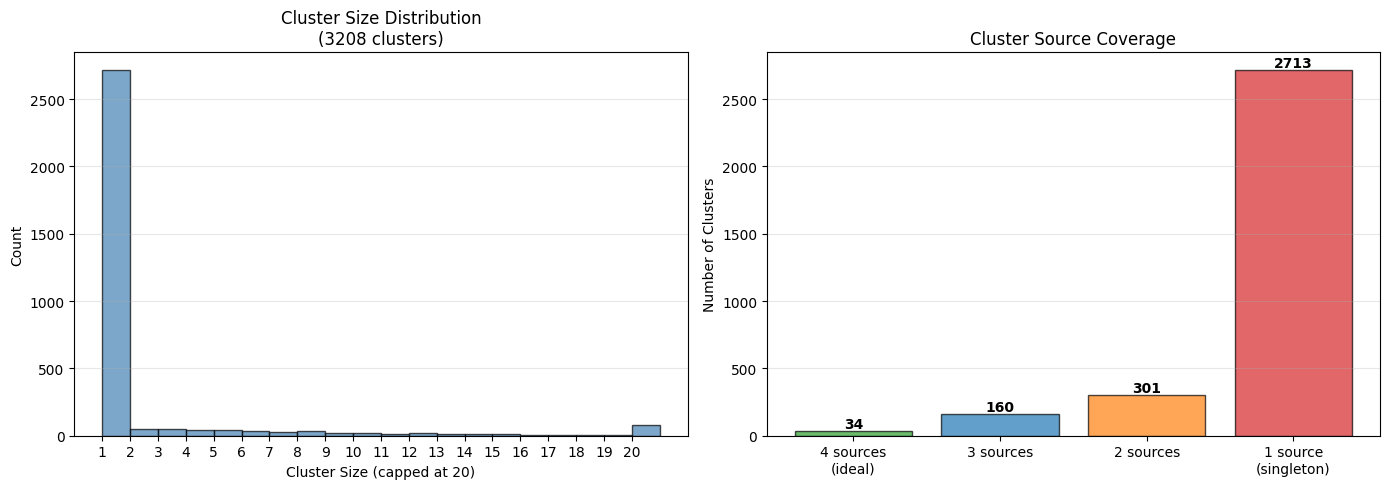


Saved: ../../data/review/q2q_4dataset/cluster_statistics.png


In [13]:
# Visualize cluster statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cluster size distribution
ax1 = axes[0]
sizes = [len(members) for members in clusters.values()]
# Cap at 20 for visualization
sizes_capped = [min(s, 20) for s in sizes]
ax1.hist(sizes_capped, bins=range(1, 22), edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('Cluster Size (capped at 20)')
ax1.set_ylabel('Count')
ax1.set_title(f'Cluster Size Distribution\n({len(clusters)} clusters)')
ax1.set_xticks(range(1, 21))
ax1.grid(True, alpha=0.3, axis='y')

# Source coverage
ax2 = axes[1]
coverage = stats["coverage_by_n"]
labels = ['4 sources\n(ideal)', '3 sources', '2 sources', '1 source\n(singleton)']
values = [coverage[4], coverage[3], coverage[2], coverage[1]]
colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']
bars = ax2.bar(labels, values, color=colors, edgecolor='black', alpha=0.7)
ax2.set_ylabel('Number of Clusters')
ax2.set_title('Cluster Source Coverage')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, values):
    if val > 0:
        ax2.annotate(f'{val}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cluster_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved: {OUTPUT_DIR / 'cluster_statistics.png'}")

## Cell 7: TwinsUK Integration Summary

In [14]:
# Analyze TwinsUK integration specifically
print("="*60)
print("TwinsUK Integration Summary")
print("="*60)

# Count TwinsUK questions in clusters
twinsuk_in_clusters = 0
twinsuk_singletons = 0
twinsuk_with_matches = defaultdict(int)  # Which datasets TwinsUK matches with

for root, members in clusters.items():
    twinsuk_members = [m for m in members if m.startswith("twinsuk_")]
    other_sources = set()
    
    for qid in members:
        if qid in question_lookup and not qid.startswith("twinsuk_"):
            src = question_lookup[qid].get("metadata", {}).get("source_questionnaire", "Unknown")
            other_sources.add(src)
    
    if twinsuk_members:
        if len(members) == 1:
            twinsuk_singletons += len(twinsuk_members)
        else:
            twinsuk_in_clusters += len(twinsuk_members)
            for src in other_sources:
                twinsuk_with_matches[src] += len(twinsuk_members)

total_twinsuk = len(questions_by_source["TwinsUK"])
print(f"\nTotal TwinsUK questions: {total_twinsuk}")
print(f"TwinsUK in multi-question clusters: {twinsuk_in_clusters} ({100*twinsuk_in_clusters/total_twinsuk:.1f}%)")
print(f"TwinsUK as singletons (no match ≥{THRESHOLD}): {twinsuk_singletons} ({100*twinsuk_singletons/total_twinsuk:.1f}%)")

print(f"\nTwinsUK matches by target dataset:")
for src in ["Arivale", "Israeli10K", "UKBB"]:
    count = twinsuk_with_matches.get(src, 0)
    print(f"  TwinsUK ↔ {src}: {count} TwinsUK questions")

TwinsUK Integration Summary

Total TwinsUK questions: 7801
TwinsUK in multi-question clusters: 5409 (69.3%)
TwinsUK as singletons (no match ≥0.5): 2392 (30.7%)

TwinsUK matches by target dataset:
  TwinsUK ↔ Arivale: 3687 TwinsUK questions
  TwinsUK ↔ Israeli10K: 2903 TwinsUK questions
  TwinsUK ↔ UKBB: 2346 TwinsUK questions


In [15]:
# Compare TwinsUK match rate to other datasets
print("\nMatch rates by source (questions with ≥1 match above threshold):")

for source in ALL_SOURCES:
    source_questions = set(q["id"] for q in questions_by_source[source])
    in_multi_cluster = 0
    
    for root, members in clusters.items():
        if len(members) > 1:
            for qid in members:
                if qid in source_questions:
                    in_multi_cluster += 1
    
    total = len(source_questions)
    pct = 100 * in_multi_cluster / total if total > 0 else 0
    print(f"  {source:12s}: {in_multi_cluster:5d} / {total:5d} ({pct:5.1f}%)")


Match rates by source (questions with ≥1 match above threshold):
  Arivale     :   474 /   561 ( 84.5%)
  Israeli10K  :   472 /   514 ( 91.8%)
  UKBB        :   307 /   499 ( 61.5%)
  TwinsUK     :  5409 /  7801 ( 69.3%)


## Cell 8: Generate All Cluster Pairs

In [16]:
# Build edge lookup for pairwise similarity
edge_lookup: dict[tuple[str, str], float] = {}
for e in all_edges:
    # Store both directions
    edge_lookup[(e.source_id, e.target_id)] = e.similarity
    edge_lookup[(e.target_id, e.source_id)] = e.similarity


@dataclass
class ClusterPair:
    """A pair of questions from a cluster for review."""
    source_id: str
    source_text: str
    source_dataset: str
    target_id: str
    target_text: str
    target_dataset: str
    similarity: float
    edge_type: str  # "direct" or "transitive"
    cluster_id: int
    cluster_size: int


# Generate all cross-source pairs within each cluster
all_pairs: list[ClusterPair] = []
cluster_id = 0

for root, members in clusters.items():
    # Skip singletons
    if len(members) < 2:
        continue
    
    cluster_id += 1
    cluster_size = len(members)
    
    # Get all question details with their sources
    member_details = []
    for qid in members:
        if qid in question_lookup:
            q = question_lookup[qid]
            src = q.get("metadata", {}).get("source_questionnaire", "Unknown")
            member_details.append((qid, q["name"], src))
    
    # Generate all pairs (combinations of 2)
    for (id1, text1, src1), (id2, text2, src2) in combinations(member_details, 2):
        # Only cross-source pairs
        if src1 == src2:
            continue
        
        # Get similarity (may not exist if not best-match pair)
        similarity = edge_lookup.get((id1, id2), 0.0)
        
        # Determine if this is a direct edge or transitive
        edge_key = tuple(sorted([id1, id2]))
        edge_type = "direct" if edge_key in direct_edges else "transitive"
        
        # Normalize order: source alphabetically before target
        if src1 < src2:
            all_pairs.append(ClusterPair(
                source_id=id1, source_text=text1, source_dataset=src1,
                target_id=id2, target_text=text2, target_dataset=src2,
                similarity=similarity, edge_type=edge_type,
                cluster_id=cluster_id, cluster_size=cluster_size
            ))
        else:
            all_pairs.append(ClusterPair(
                source_id=id2, source_text=text2, source_dataset=src2,
                target_id=id1, target_text=text1, target_dataset=src1,
                similarity=similarity, edge_type=edge_type,
                cluster_id=cluster_id, cluster_size=cluster_size
            ))

print(f"Total cross-source pairs generated: {len(all_pairs)}")
print(f"  Direct edges: {sum(1 for p in all_pairs if p.edge_type == 'direct')}")
print(f"  Transitive edges: {sum(1 for p in all_pairs if p.edge_type == 'transitive')}")

Total cross-source pairs generated: 18250
  Direct edges: 6167
  Transitive edges: 12083


In [17]:
# Analyze pairs by source combination
print("\nPairs by source combination:")

pair_combos = defaultdict(int)
for p in all_pairs:
    combo = f"{p.source_dataset} ↔ {p.target_dataset}"
    pair_combos[combo] += 1

for combo, count in sorted(pair_combos.items()):
    print(f"  {combo}: {count}")

# Pairs by cluster size
print("\nPairs by cluster size:")
pairs_by_size = defaultdict(int)
for p in all_pairs:
    pairs_by_size[p.cluster_size] += 1

for size in sorted(pairs_by_size.keys())[:10]:
    count = pairs_by_size[size]
    theoretical = size * (size - 1) // 2  # Max pairs in a cluster
    print(f"  Cluster size {size}: {count} pairs")


Pairs by source combination:
  Arivale ↔ Israeli10K: 388
  Arivale ↔ TwinsUK: 7252
  Arivale ↔ UKBB: 143
  Israeli10K ↔ TwinsUK: 6341
  Israeli10K ↔ UKBB: 422
  TwinsUK ↔ UKBB: 3704

Pairs by cluster size:
  Cluster size 2: 48 pairs
  Cluster size 3: 105 pairs
  Cluster size 4: 148 pairs
  Cluster size 5: 224 pairs
  Cluster size 6: 291 pairs
  Cluster size 7: 258 pairs
  Cluster size 8: 385 pairs
  Cluster size 9: 322 pairs
  Cluster size 10: 414 pairs
  Cluster size 11: 236 pairs


/tmp/ipykernel_3381563/2208600084.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


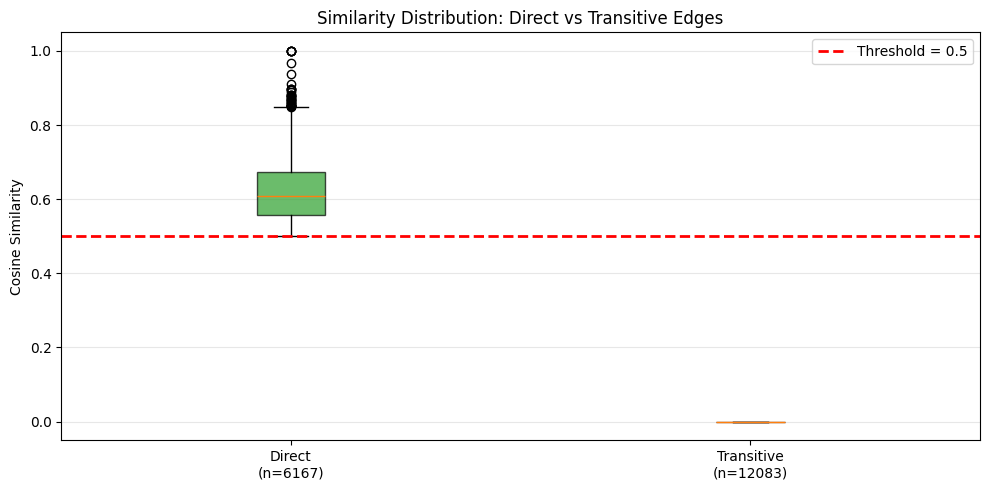


Direct edge statistics:
  Mean: 0.6215
  Median: 0.6093

Transitive edge statistics:
  Mean: 0.0000
  Median: 0.0000

Saved: ../../data/review/q2q_4dataset/direct_vs_transitive.png


In [18]:
# Visualize direct vs transitive similarity distributions
fig, ax = plt.subplots(figsize=(10, 5))

direct_sims = [p.similarity for p in all_pairs if p.edge_type == "direct"]
transitive_sims = [p.similarity for p in all_pairs if p.edge_type == "transitive"]

data = [direct_sims, transitive_sims]
labels = [f'Direct\n(n={len(direct_sims)})', f'Transitive\n(n={len(transitive_sims)})']

bp = ax.boxplot(data, labels=labels, patch_artist=True)
colors = ['#2ca02c', '#ff7f0e']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(y=THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold = {THRESHOLD}')
ax.set_ylabel('Cosine Similarity')
ax.set_title('Similarity Distribution: Direct vs Transitive Edges')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'direct_vs_transitive.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDirect edge statistics:")
print(f"  Mean: {np.mean(direct_sims):.4f}")
print(f"  Median: {np.median(direct_sims):.4f}")

if transitive_sims:
    print(f"\nTransitive edge statistics:")
    print(f"  Mean: {np.mean(transitive_sims):.4f}")
    print(f"  Median: {np.median(transitive_sims):.4f}")

print(f"\nSaved: {OUTPUT_DIR / 'direct_vs_transitive.png'}")

## Cell 9: Identify Existing Pairs (for Vote Migration)

In [19]:
# Load existing pairs from previous 3-dataset campaign
existing_pair_set: set[tuple[str, str]] = set()

if EXISTING_PAIRS_PATH.exists():
    print(f"Loading existing pairs from {EXISTING_PAIRS_PATH}...")
    existing_df = pd.read_csv(EXISTING_PAIRS_PATH, sep="\t")
    
    for _, row in existing_df.iterrows():
        # Store both orderings
        existing_pair_set.add((row["source_id"], row["target_id"]))
        existing_pair_set.add((row["target_id"], row["source_id"]))
    
    print(f"Loaded {len(existing_df)} existing pairs ({len(existing_pair_set)//2} unique)")
else:
    print(f"No existing pairs file found at {EXISTING_PAIRS_PATH}")
    print("All pairs will be treated as new.")

Loading existing pairs from ../../data/review/q2q_expertintheloop.tsv...
Loaded 155 existing pairs (155 unique)


In [20]:
# Flag which new pairs have existing votes
pairs_with_votes = 0
new_pairs = 0

for pair in all_pairs:
    if (pair.source_id, pair.target_id) in existing_pair_set:
        pairs_with_votes += 1
    else:
        new_pairs += 1

print(f"\nPair status summary:")
print(f"  Total pairs: {len(all_pairs)}")
print(f"  With existing votes (can migrate): {pairs_with_votes}")
print(f"  Completely new pairs: {new_pairs}")

if pairs_with_votes > 0:
    print(f"\n✓ {pairs_with_votes} pairs can have votes migrated from previous campaign")


Pair status summary:
  Total pairs: 18250
  With existing votes (can migrate): 77
  Completely new pairs: 18173

✓ 77 pairs can have votes migrated from previous campaign


## Cell 10: Export for EITL Upload

In [21]:
# Export TSV for EITL upload
rows = []

for pair in all_pairs:
    has_existing = (pair.source_id, pair.target_id) in existing_pair_set
    
    rows.append({
        "source_id": pair.source_id,
        "source_text": pair.source_text,
        "source_dataset": pair.source_dataset,
        "target_id": pair.target_id,
        "target_text": pair.target_text,
        "target_dataset": pair.target_dataset,
        "llm_confidence": round(pair.similarity, 4),
        "llm_reasoning": pair.edge_type,  # "direct" or "transitive"
        "cluster_id": pair.cluster_id,
        "cluster_size": pair.cluster_size,
        "has_existing_votes": has_existing,
    })

pairs_df = pd.DataFrame(rows)

# Sort by cluster_id, then source_dataset, then target_dataset
pairs_df = pairs_df.sort_values(["cluster_id", "source_dataset", "target_dataset"])

# Save TSV
tsv_path = OUTPUT_DIR / "q2q_4dataset_pairs.tsv"
pairs_df.to_csv(tsv_path, sep="\t", index=False)

print(f"Exported {len(pairs_df)} pairs to {tsv_path}")
print(f"\nColumns: {list(pairs_df.columns)}")
print(f"\nFirst few rows:")
pairs_df.head()

Exported 18250 pairs to ../../data/review/q2q_4dataset/q2q_4dataset_pairs.tsv

Columns: ['source_id', 'source_text', 'source_dataset', 'target_id', 'target_text', 'target_dataset', 'llm_confidence', 'llm_reasoning', 'cluster_id', 'cluster_size', 'has_existing_votes']

First few rows:


,source_id,source_text,source_dataset,target_id,target_text,target_dataset,llm_confidence,llm_reasoning,cluster_id,cluster_size,has_existing_votes
2,arivale_691de9fe5d58,Do you follow a specific dietary plan?,Arivale,twinsuk_427d932e36c5,Eating habits \ How conscious are you of what ...,TwinsUK,0.5037,direct,1,9,False
3,arivale_691de9fe5d58,Do you follow a specific dietary plan?,Arivale,twinsuk_f4614cb3a3af,Please tick the box that best reflects how fre...,TwinsUK,0.5236,direct,1,9,False
4,arivale_691de9fe5d58,Do you follow a specific dietary plan?,Arivale,twinsuk_f645fbfe0793,Eating habits \ How often do you diet?,TwinsUK,0.6100,direct,1,9,False
5,arivale_691de9fe5d58,Do you follow a specific dietary plan?,Arivale,twinsuk_a0088aa387f3,"Eating habits \ I avoid ""stocking up"" on tempt...",TwinsUK,0.5125,direct,1,9,False
6,arivale_691de9fe5d58,Do you follow a specific dietary plan?,Arivale,twinsuk_4cccd7ce683c,Are you currently on a diet to lose weight?,TwinsUK,0.5635,direct,1,9,False


In [22]:
# Also export cluster details JSON
cluster_details = []
cluster_id = 0

for root, members in clusters.items():
    if len(members) < 2:
        continue
    
    cluster_id += 1
    
    questions_in_cluster = []
    sources = set()
    
    for qid in members:
        if qid in question_lookup:
            q = question_lookup[qid]
            src = q.get("metadata", {}).get("source_questionnaire", "Unknown")
            sources.add(src)
            questions_in_cluster.append({
                "id": qid,
                "text": q["name"],
                "source": src,
            })
    
    # Find edges within cluster
    cluster_edges = []
    for e in all_edges:
        if e.source_id in members and e.target_id in members:
            if e.similarity >= THRESHOLD:
                cluster_edges.append({
                    "from": e.source_id,
                    "to": e.target_id,
                    "similarity": round(e.similarity, 4),
                })
    
    avg_sim = np.mean([e["similarity"] for e in cluster_edges]) if cluster_edges else 0.0
    
    cluster_details.append({
        "cluster_id": cluster_id,
        "size": len(members),
        "sources": sorted(sources),
        "num_sources": len(sources),
        "questions": questions_in_cluster,
        "edges": cluster_edges,
        "avg_similarity": round(avg_sim, 4),
    })

# Sort by num_sources desc, then avg_similarity desc
cluster_details.sort(key=lambda x: (-x["num_sources"], -x["avg_similarity"]))

# Re-number after sorting
for i, c in enumerate(cluster_details):
    c["cluster_id"] = i + 1

# Save JSON
json_output = {
    "clusters": cluster_details,
    "statistics": stats,
    "metadata": {
        "generated_at": datetime.now(UTC).isoformat(),
        "total_questions": len(questions),
        "total_edges": len(all_edges),
        "edges_above_threshold": edges_used,
        "total_pairs": len(all_pairs),
        "embedding_model": EMBEDDING_MODEL,
        "threshold": THRESHOLD,
        "sources": ALL_SOURCES,
    }
}

json_path = OUTPUT_DIR / "q2q_4dataset_clusters.json"
with open(json_path, "w") as f:
    json.dump(json_output, f, indent=2)

print(f"Exported cluster details to {json_path}")

Exported cluster details to ../../data/review/q2q_4dataset/q2q_4dataset_clusters.json


In [ ]:
# Cell 10b: Export FILTERED pairs (size 2-4 only) for EITL upload
# These smaller clusters are higher quality and more manageable for review

pairs_filtered = pairs_df[pairs_df["cluster_size"] <= 4].copy()

# Save filtered export
filtered_path = OUTPUT_DIR / "q2q_4dataset_pairs_size2-4.tsv"
pairs_filtered.to_csv(filtered_path, sep="\t", index=False)

print(f"Filtered export (size 2-4 only):")
print(f"  Total pairs: {len(pairs_filtered)}")
print(f"  With existing votes: {pairs_filtered['has_existing_votes'].sum()}")
print(f"  Saved to: {filtered_path}")

# Breakdown by cluster size
print(f"\nBy cluster size:")
for size in sorted(pairs_filtered["cluster_size"].unique()):
    count = (pairs_filtered["cluster_size"] == size).sum()
    print(f"  Size {size}: {count} pairs")

In [ ]:
# Cell 10c: Export ALL pairs organized by cluster, with columns ready for human review

full_export_rows = []

for pair in all_pairs:
    has_existing = (pair.source_id, pair.target_id) in existing_pair_set

    # Determine cluster status based on size
    if pair.cluster_size <= 4:
        cluster_status = "review_ready"
    elif pair.cluster_size <= 10:
        cluster_status = "medium_cluster"
    else:
        cluster_status = "large_cluster_needs_review"

    full_export_rows.append({
        "cluster_id": pair.cluster_id,
        "cluster_size": pair.cluster_size,
        "cluster_status": cluster_status,
        "source_text": pair.source_text,
        "target_text": pair.target_text,
        "source_id": pair.source_id,
        "target_id": pair.target_id,
        "source_dataset": pair.source_dataset,
        "target_dataset": pair.target_dataset,
        "cosine_similarity": round(pair.similarity, 4),
        "edge_type": pair.edge_type,  # "direct" or "transitive"
        "human_decision": "",  # To be filled by reviewer
        "reviewer": "",  # To be filled by reviewer
        "notes": "",  # Optional reviewer notes
    })

full_df = pd.DataFrame(full_export_rows)

# Sort by cluster_id, then by source_dataset for consistent ordering within clusters
full_df = full_df.sort_values(["cluster_id", "source_dataset", "target_dataset"])

# Save full export
full_export_path = OUTPUT_DIR / "q2q_4dataset_all_clusters.tsv"
full_df.to_csv(full_export_path, sep="\t", index=False)

print(f"Exported {len(full_df)} pairs across all clusters to {full_export_path}")
print(f"\nCluster status breakdown:")
print(full_df["cluster_status"].value_counts())
print(f"\nEdge type breakdown:")
print(full_df["edge_type"].value_counts())

## Cell 11: Summary & Validation

In [23]:
# Validation checks
print("="*60)
print("VALIDATION CHECKS")
print("="*60)

# 1. No same-source pairs
same_source = sum(1 for p in all_pairs if p.source_dataset == p.target_dataset)
print(f"\n1. Same-source pairs: {same_source}")
if same_source == 0:
    print("   ✓ PASS: No same-source pairs")
else:
    print("   ✗ FAIL: Found same-source pairs!")

# 2. No duplicate pairs
pair_keys = [(p.source_id, p.target_id) for p in all_pairs]
unique_pairs = len(set(pair_keys))
print(f"\n2. Duplicate check: {len(pair_keys)} total, {unique_pairs} unique")
if unique_pairs == len(pair_keys):
    print("   ✓ PASS: No duplicate pairs")
else:
    print(f"   ✗ FAIL: {len(pair_keys) - unique_pairs} duplicate pairs!")

# 3. All similarity scores valid
invalid_sims = sum(1 for p in all_pairs if p.similarity < 0 or p.similarity > 1)
print(f"\n3. Invalid similarity scores: {invalid_sims}")
if invalid_sims == 0:
    print("   ✓ PASS: All similarities in [0, 1]")
else:
    print("   ✗ FAIL: Found invalid similarity scores!")

# 4. All sources represented
sources_in_pairs = set()
for p in all_pairs:
    sources_in_pairs.add(p.source_dataset)
    sources_in_pairs.add(p.target_dataset)
missing_sources = set(ALL_SOURCES) - sources_in_pairs
print(f"\n4. Sources in pairs: {sorted(sources_in_pairs)}")
if not missing_sources:
    print("   ✓ PASS: All sources represented")
else:
    print(f"   ✗ FAIL: Missing sources: {missing_sources}")

VALIDATION CHECKS

1. Same-source pairs: 0
   ✓ PASS: No same-source pairs

2. Duplicate check: 18250 total, 18250 unique
   ✓ PASS: No duplicate pairs

3. Invalid similarity scores: 1
   ✗ FAIL: Found invalid similarity scores!

4. Sources in pairs: ['Arivale', 'Israeli10K', 'TwinsUK', 'UKBB']
   ✓ PASS: All sources represented


In [ ]:
# Final summary
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

print(f"\nConfiguration:")
print(f"  Embedding model: {EMBEDDING_MODEL}")
print(f"  Similarity threshold: {THRESHOLD}")
print(f"  Sources: {', '.join(ALL_SOURCES)}")

print(f"\nData:")
for source in ALL_SOURCES:
    print(f"  {source}: {len(questions_by_source[source])} questions")
print(f"  Total: {len(questions)} questions")

print(f"\nClustering:")
print(f"  Total edges generated: {len(all_edges)}")
print(f"  Edges above threshold: {edges_used} ({100*edges_used/len(all_edges):.1f}%)")
print(f"  Total clusters: {len(clusters)}")
print(f"  Multi-question clusters: {sum(1 for c in clusters.values() if len(c) > 1)}")

print(f"\nPairs for review:")
print(f"  Total pairs: {len(all_pairs)}")
print(f"  Direct edges: {sum(1 for p in all_pairs if p.edge_type == 'direct')}")
print(f"  Transitive edges: {sum(1 for p in all_pairs if p.edge_type == 'transitive')}")
print(f"  With existing votes: {pairs_with_votes}")
print(f"  New pairs: {new_pairs}")

# Filtered summary
filtered_count = len(pairs_df[pairs_df["cluster_size"] <= 4])
filtered_with_votes = pairs_df[pairs_df["cluster_size"] <= 4]["has_existing_votes"].sum()
print(f"\nFiltered pairs (size 2-4 only):")
print(f"  Total pairs: {filtered_count}")
print(f"  With existing votes: {filtered_with_votes}")

print(f"\nOutput files:")
print(f"  {OUTPUT_DIR / 'q2q_4dataset_pairs.tsv'} (all {len(all_pairs)} pairs)")
print(f"  {OUTPUT_DIR / 'q2q_4dataset_pairs_size2-4.tsv'} (filtered {filtered_count} pairs for EITL)")
print(f"  {OUTPUT_DIR / 'q2q_4dataset_all_clusters.tsv'} (all pairs with review columns)")
print(f"  {OUTPUT_DIR / 'q2q_4dataset_clusters.json'}")
print(f"  {OUTPUT_DIR / 'edge_similarity_distribution.png'}")
print(f"  {OUTPUT_DIR / 'cluster_statistics.png'}")
print(f"  {OUTPUT_DIR / 'direct_vs_transitive.png'}")

print(f"\n" + "="*60)
print("Ready for EITL upload!")
print("="*60)

## Appendix: Sample Clusters for Review

In [25]:
# Display top 4-way clusters (ideal matches)
print("="*70)
print("TOP 4-WAY CLUSTERS (All Four Sources)")
print("="*70)

four_way = [c for c in cluster_details if c["num_sources"] == 4]
print(f"\nFound {len(four_way)} clusters with all 4 sources")

for cluster in four_way[:10]:  # Show top 10
    print(f"\n--- Cluster {cluster['cluster_id']} (size={cluster['size']}, avg_sim={cluster['avg_similarity']:.3f}) ---")
    
    by_source = defaultdict(list)
    for q in cluster["questions"]:
        by_source[q["source"]].append(q)
    
    for source in ALL_SOURCES:
        if source in by_source:
            for q in by_source[source]:
                text_preview = q["text"][:60] + "..." if len(q["text"]) > 60 else q["text"]
                print(f"  [{source:10s}] {text_preview}")

TOP 4-WAY CLUSTERS (All Four Sources)

Found 34 clusters with all 4 sources

--- Cluster 1 (size=16, avg_sim=0.771) ---
  [Arivale   ] Macular degeneration
  [Israeli10K] Which eye(s) affected by macular degeneration
  [Israeli10K] Age macular degeneration diagnosed
  [Israeli10K] Eye health AMD age
  [UKBB      ] ACE touchscreen question Which eye(s) are affected by macula...
  [UKBB      ] ACE touchscreen question What was your age when macular dege...
  [TwinsUK   ] Do you believe that any of the following diseases 'run in yo...
  [TwinsUK   ] Has a doctor EVER diagnosed or treated you for any of the fo...
  [TwinsUK   ] Age at 1st diagnosis \ Age-related macular degeneration (AMD...
  [TwinsUK   ] Age-related Macular Degeneration (AMD)\Have you ever been to...
  [TwinsUK   ] Age-related Macular Degeneration (AMD)\Have you ever been to...
  [TwinsUK   ] Age-related Macular Degeneration (AMD)\Have you ever receive...
  [TwinsUK   ] Has a doctor ever diagnosed or treated you for any o

In [26]:
# Display suspicious large clusters
print("\n" + "="*70)
print("LARGE CLUSTERS (>10 questions) - May Need Manual Review")
print("="*70)

large_clusters = [c for c in cluster_details if c["size"] > 10]
print(f"\nFound {len(large_clusters)} clusters with >10 questions")

for cluster in large_clusters[:5]:  # Show top 5
    sources_str = ", ".join(cluster["sources"])
    print(f"\n--- Cluster {cluster['cluster_id']} (size={cluster['size']}, sources={sources_str}) ---")
    
    for q in cluster["questions"][:15]:  # Show first 15
        text_preview = q["text"][:55] + "..." if len(q["text"]) > 55 else q["text"]
        print(f"  [{q['source']:10s}] {text_preview}")
    
    if len(cluster["questions"]) > 15:
        print(f"  ... and {len(cluster['questions']) - 15} more questions")
    
    print(f"  ⚠️ Large cluster - may represent overly broad concept")


LARGE CLUSTERS (>10 questions) - May Need Manual Review

Found 182 clusters with >10 questions

--- Cluster 1 (size=16, sources=Arivale, Israeli10K, TwinsUK, UKBB) ---
  [Arivale   ] Macular degeneration
  [Israeli10K] Which eye(s) affected by macular degeneration
  [Israeli10K] Age macular degeneration diagnosed
  [Israeli10K] Eye health AMD age
  [UKBB      ] ACE touchscreen question Which eye(s) are affected by m...
  [UKBB      ] ACE touchscreen question What was your age when macular...
  [TwinsUK   ] Do you believe that any of the following diseases 'run ...
  [TwinsUK   ] Has a doctor EVER diagnosed or treated you for any of t...
  [TwinsUK   ] Age at 1st diagnosis \ Age-related macular degeneration...
  [TwinsUK   ] Age-related Macular Degeneration (AMD)\Have you ever be...
  [TwinsUK   ] Age-related Macular Degeneration (AMD)\Have you ever be...
  [TwinsUK   ] Age-related Macular Degeneration (AMD)\Have you ever re...
  [TwinsUK   ] Has a doctor ever diagnosed or treated you 